# Read in the BNC dataset that has been standardized for American spellings

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('bnc_collocations_ame.csv')
# # create a new df, but exclude rows with cooccurrence of 1
# df = input_df[input_df['cooccurrence'] > 1]
df

,w1,w2,w1_CEFR,w2_CEFR,relation,cooccurrence,freq_w1,freq_w2,w1_in_rel,w2_in_rel
0,take,place,A1,A1,obj,11798.0,177452,67842,129444,20351
1,see,P.,A1,-,obj,7424.0,191492,15431,79100,7457
2,have,effect,A1,A2,obj,5666.0,1272829,34971,298001,14769
3,have,time,A1,A1,obj,4508.0,1272829,189496,298001,27196
4,do,thing,A1,A1,obj,4204.0,547768,76942,45186,23360
...,...,...,...,...,...,...,...,...,...,...
1177230,get,sto,A1,-,obj,1.0,216478,27,89065,1
1177231,get,stockmarket,A1,-,obj,1.0,216478,224,89065,31
1177232,get,stockpile,A1,B2,obj,1.0,216478,204,89065,52
1177233,get,stoppage,A1,-,obj,1.0,216478,204,89065,59


# This is slightly adapted from Fukuda and Tono (2022)
https://drive.google.com/drive/folders/1CxLqPpAL9UGTYd234siJgCOJNGv85Duw (code folder)
### code -> CollocationDataSet.py
### In the paper, we ended up using log odds ratio
### It was calculated as described here (if log_odds_ratio) and is also described in the paper

In [2]:
def AMcalc(df, measures=None):
    """
    Calculate specified association measures for collocation analysis.
    
    Parameters:
    - df: DataFrame containing collocation data
    - measures: List of measures to calculate. If None, calculates all measures.
                Available measures: ['MI', 'MI2', 'MI3', 't_score', 'z_score', 
                'simple_ll', 'Dice', 'logDice', 'log_likelihood', 'chi_squared',
                'log_odds_ratio']
 
    Returns:
    - DataFrame with calculated association measures
    """
    # If no specific measures are requested, calculate all of them
    if measures is None:
        measures = ['MI', 'MI2', 'MI3', 't_score', 'z_score', 'simple_ll', 
                   'Dice', 'logDice', 'log_likelihood', 'chi_squared', 
                   'log_odds_ratio']
    
    # Basic frequency information
    n = df['cooccurrence'].values.sum()
    c1 = df['w1_in_rel'].values
    r1 = df['w2_in_rel'].values
    o11 = df['cooccurrence'].values
    e11 = (r1 * c1) / n
    
    # Always add expected frequency
    df['expected_freq'] = e11
    
    # Simple association measures calculation
    if 'MI' in measures:
        # Calculate Mutual Information
        df['MI'] = np.log2(o11/e11)
    
    if 'MI2' in measures:
        # Calculate MI^2
        df['MI2'] = np.log2(o11**2/e11)
    
    if 'MI3' in measures:
        # Calculate MI^3
        df['MI3'] = np.log2(o11**3/e11)
    
    if 't_score' in measures:
        # Calculate T-score
        df['t_score'] = (o11-e11)/(np.sqrt(o11))
    
    if 'z_score' in measures:
        # Calculate Z-score
        df['z_score'] = (o11 - e11)/np.sqrt(e11)
    
    if 'simple_ll' in measures:
        # Calculate simple log-likelihood
        df['simple_ll'] = 2*(o11*np.log(o11/e11)-(o11-e11))
    
    if 'Dice' in measures:
        # Calculate Dice coefficient
        df['Dice'] = 2 * (o11/(c1+r1))
    
    if 'logDice' in measures:
        # Calculate logDice
        dice = 2 * (o11/(c1+r1))
        df['logDice'] = 14 + np.log2(dice)
    
    # Association measures using contingency table
    if any(m in measures for m in ['log_likelihood', 'chi_squared', 'log_odds_ratio']):
        # Create observed contingency table
        #                  | collocate present | collocate absent | total
        # node present     | o11               | o12              | r1
        # node absent      | o21               | o22              | r2
        # total           | c1                | c2               | n
        
        o12 = r1 - o11
        o21 = c1 - o11
        o22 = n - r1 - c1 + o11
        c2 = n - c1
        r2 = n - r1
        
        # Create expected contingency table
        e12 = (r1*c2)/n
        e21 = (r2*c1)/n
        e22 = (r2*c2)/n
        
        if 'log_likelihood' in measures:
            # Calculate log-likelihood
            df['log_likelihood'] = (2*(o11*np.log(o11/e11))) + (2*(o12*np.log(o12/e12))) + \
                                  (2*(o21*np.log(o21/e21))) + (2*(o22*np.log(o22/e22)))
        
        if 'chi_squared' in measures:
            # Calculate chi-squared
            df['chi_squared'] = ((o11 - e11)**2 / e11) + ((o12 - e12)**2 / e12) + \
                               ((o21 - e21)**2 / e21) + ((o22 - e22)**2 / e22)
                               
        # if 'log_odds_ratio' in measures:
        #     # Calculate log odds ratio: log(O11*O22/O12*O21)
        #     # Add small constant to avoid division by zero or log(0)
        #     epsilon = 1e-10
        #     df['log_odds_ratio'] = np.log((o11 * o22 + epsilon) / (o12 * o21 + epsilon))

        # based on Gries (2022, p. 7) "here I’m using a discounted version of the odds ratio, which involves adding 0.5 to every frequency first"
        if 'log_odds_ratio' in measures:
            # Apply continuity correction to avoid log(0) and stabilize low-frequency results
            o11_adj = o11 + 0.5
            o12_adj = o12 + 0.5
            o21_adj = o21 + 0.5
            o22_adj = o22 + 0.5

            df['log_odds_ratio'] = np.log((o11_adj * o22_adj) / (o12_adj * o21_adj))    

    return df

# We were intitially considering logDice, so it is also added to the dataset here 
#### but we only used log odds ratio

In [3]:
# am_df = AMcalc(df, measures='logDice')
# am_df.to_csv('bnc_collocations_ame_logDice.csv', index=False)

am_df = AMcalc(df, measures=['log_odds_ratio', 'logDice'])
am_df.to_csv('bnc_collocations_ame_AMs.csv', index=False)

am_df

,w1,w2,w1_CEFR,w2_CEFR,relation,cooccurrence,freq_w1,freq_w2,w1_in_rel,w2_in_rel,expected_freq,logDice,log_odds_ratio
0,take,place,A1,A1,obj,11798.0,177452,67842,129444,20351,568.587881,11.333625,3.964688
1,see,P.,A1,-,obj,7424.0,191492,15431,79100,7457,127.312353,11.456618,9.552583
2,have,effect,A1,A2,obj,5666.0,1272829,34971,298001,14769,949.945591,9.213372,2.220404
3,have,time,A1,A1,obj,4508.0,1272829,189496,298001,27196,1749.253185,8.827317,1.071499
4,do,thing,A1,A1,obj,4204.0,547768,76942,45186,23360,227.827768,10.972762,3.197361
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177230,get,sto,A1,-,obj,1.0,216478,27,89065,1,0.019224,-1.442587,5.030818
1177231,get,stockmarket,A1,-,obj,1.0,216478,224,89065,31,0.595935,-1.443073,0.919938
1177232,get,stockpile,A1,B2,obj,1.0,216478,204,89065,52,0.999632,-1.443413,0.396078
1177233,get,stoppage,A1,-,obj,1.0,216478,204,89065,59,1.134198,-1.443526,0.268632


In [5]:
import pandas as pd

am_df = pd.read_csv('bnc_collocations_ame_AMs.csv')
am_df

,w1,w2,w1_CEFR,w2_CEFR,relation,cooccurrence,freq_w1,freq_w2,w1_in_rel,w2_in_rel,expected_freq,logDice,log_odds_ratio
0,take,place,A1,A1,obj,11798.0,177452,67842,129444,20351,568.587881,11.333625,3.964688
1,see,P.,A1,-,obj,7424.0,191492,15431,79100,7457,127.312353,11.456618,9.552583
2,have,effect,A1,A2,obj,5666.0,1272829,34971,298001,14769,949.945591,9.213372,2.220404
3,have,time,A1,A1,obj,4508.0,1272829,189496,298001,27196,1749.253185,8.827317,1.071499
4,do,thing,A1,A1,obj,4204.0,547768,76942,45186,23360,227.827768,10.972762,3.197361
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177230,get,sto,A1,-,obj,1.0,216478,27,89065,1,0.019224,-1.442587,5.030818
1177231,get,stockmarket,A1,-,obj,1.0,216478,224,89065,31,0.595935,-1.443073,0.919938
1177232,get,stockpile,A1,B2,obj,1.0,216478,204,89065,52,0.999632,-1.443413,0.396078
1177233,get,stoppage,A1,-,obj,1.0,216478,204,89065,59,1.134198,-1.443526,0.268632


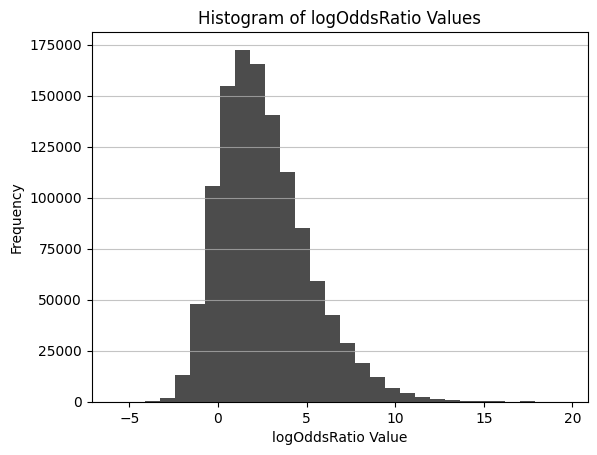

In [6]:
# create a histogram of the logDice values
# import matplotlib.pyplot as plt
# plt.hist(am_df['logDice'], bins=30, color='black', alpha=0.7)
# plt.title('Histogram of logDice Values')
# plt.xlabel('logDice Value')
# plt.ylabel('Frequency')
# plt.grid(axis='y', alpha=0.75)
# # plt.savefig('logDice_histogram.png')
# plt.show()

# create a histogram of the logDice values
import matplotlib.pyplot as plt
plt.hist(am_df['log_odds_ratio'], bins=30, color='black', alpha=0.7)
plt.title('Histogram of logOddsRatio Values')
plt.xlabel('logOddsRatio Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
# plt.savefig('logDice_histogram.png')
plt.show()